In [56]:
# ============================
# 1. Importera bibliotek
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier



from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


In [57]:
# ============================
# Ladda preprocessade data
# ============================

import joblib

X_train = joblib.load("../data/X_train.pkl")
X_test = joblib.load("../data/X_test.pkl")
y_train = joblib.load("../data/y_train.pkl")
y_test = joblib.load("../data/y_test.pkl")


In [58]:
# ============================
# Funktion för att utvärdera modeller
# Returnerar en dictionary med viktiga metrics
# ============================

def evaluate_model(model, X_test, y_test):
    # Prediktioner (0/1)
    y_pred = model.predict(X_test)
    
    # Prediktioner som sannolikheter (för ROC-AUC)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }


In [59]:
# ============================
# Logistic Regression
# ============================

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

log_reg_results = evaluate_model(log_reg, X_test, y_test)
log_reg_results


{'Accuracy': 0.8055358410220014,
 'Precision': 0.6572327044025157,
 'Recall': 0.5588235294117647,
 'F1-score': 0.6040462427745664,
 'ROC-AUC': 0.8420057351003644}

In [60]:
# ============================
# K-Nearest Neighbors
# ============================

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_results = evaluate_model(knn, X_test, y_test)
knn_results


{'Accuracy': 0.7665010645848119,
 'Precision': 0.5596816976127321,
 'Recall': 0.5641711229946524,
 'F1-score': 0.5619174434087882,
 'ROC-AUC': 0.7924294091813273}

In [61]:
# ============================
# Random Forest Classifier
# ============================

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_results = evaluate_model(rf, X_test, y_test)
rf_results


{'Accuracy': 0.7920511000709723,
 'Precision': 0.6391752577319587,
 'Recall': 0.49732620320855614,
 'F1-score': 0.5593984962406015,
 'ROC-AUC': 0.8258518690743755}

In [62]:
# ============================
# XGBoost Classifier
# ============================

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_results = evaluate_model(xgb, X_test, y_test)
xgb_results


{'Accuracy': 0.7970191625266146,
 'Precision': 0.6428571428571429,
 'Recall': 0.5294117647058824,
 'F1-score': 0.5806451612903226,
 'ROC-AUC': 0.8395489421064869}

In [63]:
# ============================
# Sammanställ resultat i en tabell
# ============================

results = pd.DataFrame({
    "Logistic Regression": log_reg_results,
    "KNN": knn_results,
    "Random Forest": rf_results,
    "XGBoost": xgb_results
})

results.T


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842006
KNN,0.766501,0.559682,0.564171,0.561917,0.792429
Random Forest,0.792051,0.639175,0.497326,0.559398,0.825852
XGBoost,0.797019,0.642857,0.529412,0.580645,0.839549


In [64]:
# ============================
# Spara bästa modellen
# ============================

import joblib

joblib.dump(xgb, "../models/best_model.pkl")


['../models/best_model.pkl']

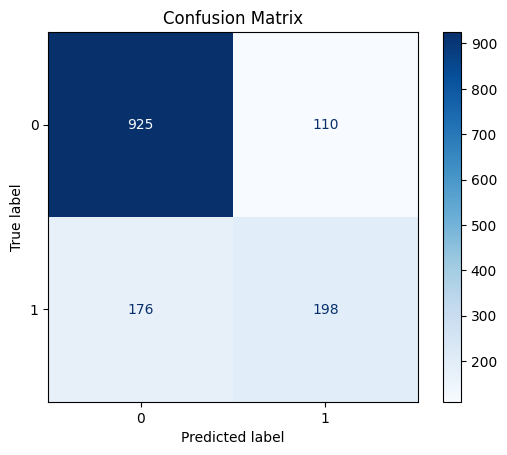

In [65]:
# ============================
# Confusion Matrix
# ============================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Prediktioner från din XGBoost-modell
y_pred = xgb.predict(X_test)

# Skapa confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plotta
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [66]:
# ============================
# Classification Report
# ============================

from sklearn.metrics import classification_report

y_pred = xgb.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



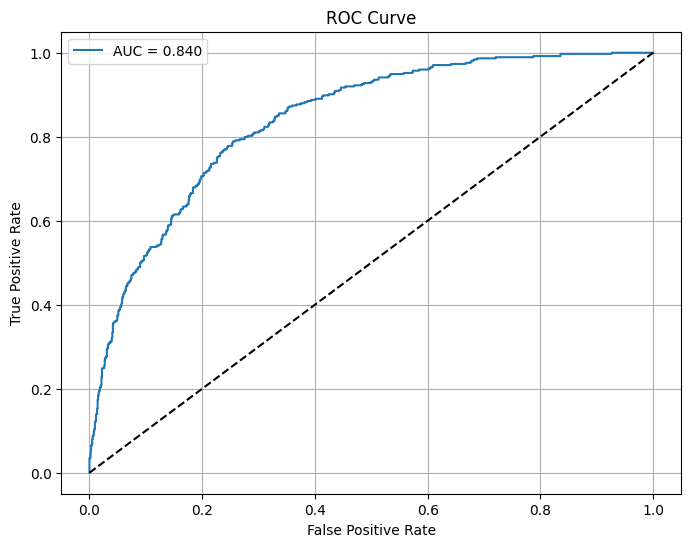

In [67]:
# ============================
# ROC Curve & AUC
# ============================

from sklearn.metrics import roc_curve, auc

# Prediktioner som sannolikheter från din XGBoost-modell
y_prob = xgb.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


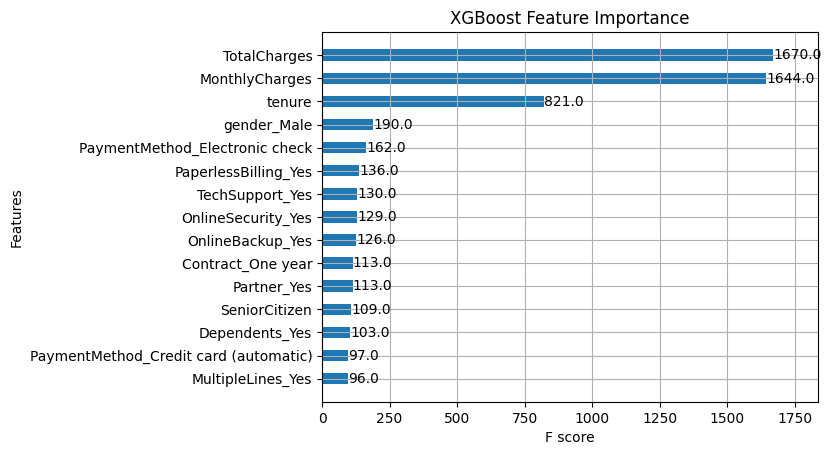

In [68]:
# ============================
# Feature Importance (XGBoost)
# ============================

import xgboost as xgb_module

xgb_module.plot_importance(xgb, max_num_features=15, height=0.5)
plt.title("XGBoost Feature Importance")
plt.show()


In [69]:
# ============================
# Sammanfattning av alla modeller
# ============================

summary_df = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Random Forest", "XGBoost"],
    "Accuracy": [
        log_reg_results["Accuracy"],
        knn_results["Accuracy"],
        rf_results["Accuracy"],
        xgb_results["Accuracy"]
    ],
    "Precision": [
        log_reg_results["Precision"],
        knn_results["Precision"],
        rf_results["Precision"],
        xgb_results["Precision"]
    ],
    "Recall": [
        log_reg_results["Recall"],
        knn_results["Recall"],
        rf_results["Recall"],
        xgb_results["Recall"]
    ],
    "F1-score": [
        log_reg_results["F1-score"],
        knn_results["F1-score"],
        rf_results["F1-score"],
        xgb_results["F1-score"]
    ],
    "ROC-AUC": [
        log_reg_results["ROC-AUC"],
        knn_results["ROC-AUC"],
        rf_results["ROC-AUC"],
        xgb_results["ROC-AUC"]
    ]
})

summary_df


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842006
1,KNN,0.766501,0.559682,0.564171,0.561917,0.792429
2,Random Forest,0.792051,0.639175,0.497326,0.559398,0.825852
3,XGBoost,0.797019,0.642857,0.529412,0.580645,0.839549
